$$ ITI \space AI-Pro: \space Intake \space 45 $$
$$ Deep \space Learning $$
$$ Lab \space no. \space 5 $$

# `01` Assignment 01

- Design your LSTM learning model to classify hand-written digits (MNIST dataset).
- To handle images as a sequence, the LSTM input can be seen as a 28 sequences
of 28 elements each (taking each row of pixels as a single time step input).
- Then, you can use dense layer(s) on top (connected to the
output of the LSTM).
- Important Notes:
  - Image Size: $28\times28$
  - Use $80\%$ of the provided training data for training and $20\%$ for validation (Keep the test data for testing after training).
  - Use $32$ units in the LSTM layer and $15\%$ recurrent dropout.
  - Use Categorical Cross Entropy for the loss calculation, `Adam` for optimization and `accuracy` for metrics.


  **Additional Requirements**:
  - Try adding a second LSTM layer before the dense layer(s).
  - Change the number of cells to $48, 96, 256$ and report the accuracy curve.

## `+` Import Libraries

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

import numpy as np
import matplotlib.pyplot as plt

# `+` Seed Value

In [2]:
SEED = 907

## `+` Load & Preprocess MNIST Dataset

**Reminder:** You might need rescaling, and/or other preprocessing methods.

In [3]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train=x_train/255.0
x_test=x_test/255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [4]:
x_train.shape

(60000, 28, 28)

In [5]:
y_train.shape

(60000,)

## `+` Set Global Parameters

In [6]:
BATCH_SIZE  =32
EPOCHS      =20

## `i` Model Design

In [8]:
model=tf.keras.models.Sequential([
    tf.keras.layers.LSTM(32,return_sequences=True,input_shape=(28,28)),
    tf.keras.layers.Dropout(0.15),
    tf.keras.layers.LSTM(16),
    tf.keras.layers.Dense(10,activation='softmax')
])

## `ii` Model Compilation & Training

In [9]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [10]:
history=model.fit(x_train,y_train,epochs=EPOCHS,batch_size=BATCH_SIZE,validation_data=(x_test,y_test))

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.6372 - loss: 1.1155 - val_accuracy: 0.9184 - val_loss: 0.2729
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.9310 - loss: 0.2446 - val_accuracy: 0.9500 - val_loss: 0.1741
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9563 - loss: 0.1528 - val_accuracy: 0.9659 - val_loss: 0.1186
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9680 - loss: 0.1100 - val_accuracy: 0.9728 - val_loss: 0.0990
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - accuracy: 0.9724 - loss: 0.0939 - val_accuracy: 0.9734 - val_loss: 0.0900
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.9779 - loss: 0.0780 - val_accuracy: 0.9782 - val_loss: 0.0767
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9805 - loss: 0.0660 - val_accuracy: 0.9774 - val_loss: 0.0781
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.9828 - loss: 0

## `iii` Model Evaluation

In [11]:
loss,acc=model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9843 - loss: 0.0567


In [12]:
print(f"Accuracy={acc:.3f}")
print("Loss=",loss)

Accuracy=0.988
Loss= 0.04664988815784454


## `iv` Result Visualization

Text(0, 0.5, 'Loss')

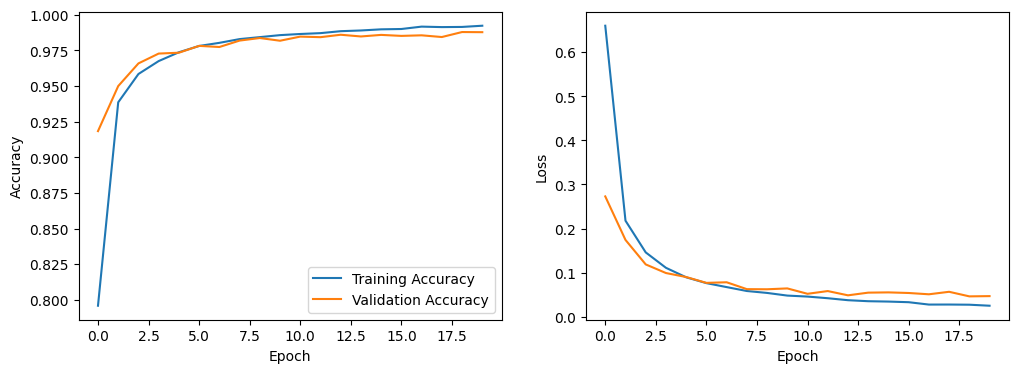

In [13]:
# Plot the training and validation accuracy and loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

## `v` Let's Visualize Model Predictions

Let's try to predict the class of some test samples and plot the results.

In [14]:
y_pred=model.predict(x_test[0].reshape(1,28,28))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step


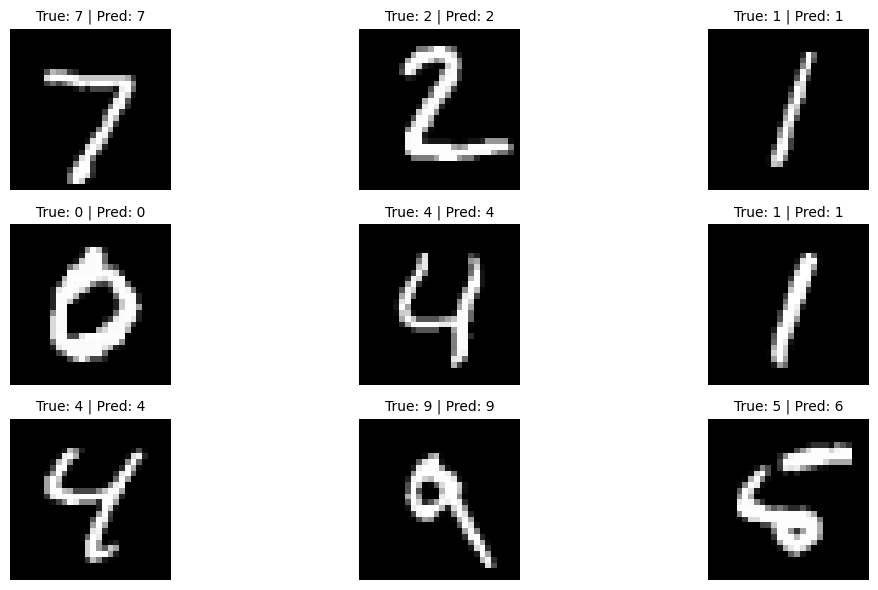

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
for j in range(9):
    plt.subplot(3, 3, j+1)
    plt.imshow(x_test[j], cmap='gray')
    y_pred = model.predict(x_test[j].reshape(1, 28, 28), verbose=0)
    predicted_label = y_pred.argmax()
    true_label = y_test[j]
    plt.title(f"True: {true_label} | Pred: {predicted_label}", fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()


**Note:** You can add more trials and explore different hyperparameters and design decisions as you want.

------------------------------

# Assignment 02
- Repeat assignment `01` using `ConvLSTM1D` layer instead of `LSTM`: An LSTM utilizing the power of convolutions. Read more [here](https://paperswithcode.com/method/convlstm) and [here](https://medium.com/neuronio/an-introduction-to-convlstm-55c9025563a7).
- Use the same parameters from assignment `01` in addition to:
  - Kernel Size -> Try $1$ and $3$. Which is better?
  - Padding = `same` or `valid` -> Is there a big difference?

**Note:** You might need to reshape the input (Hint: check `keras.layers.Reshape` layer)


IMPORTANT NOTE: Make sure to organize your solution, add proper documentation, and report your insights.
------------------------------

In [16]:
x_train.shape

(60000, 28, 28)

In [17]:
x_test=x_test.reshape(10000,28,28)

In [18]:
x_test.shape

(10000, 28, 28)

In [ ]:
model=tf.keras.models.Sequential([
    tf.keras.layers.Reshape((28, 28, 1), input_shape=(28, 28)),
    tf.keras.layers.ConvLSTM1D(filters=40, kernel_size=(3),padding='same'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(10,activation='softmax')
])

In [ ]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
history=model.fit(x_train,y_train,epochs=EPOCHS,batch_size=BATCH_SIZE,validation_data=(x_test,y_test))

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - accuracy: 0.8208 - loss: 0.5353 - val_accuracy: 0.9581 - val_loss: 0.1348
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 13ms/step - accuracy: 0.9675 - loss: 0.1083 - val_accuracy: 0.9777 - val_loss: 0.0778
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 13ms/step - accuracy: 0.9748 - loss: 0.0811 - val_accuracy: 0.9803 - val_loss: 0.0685
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9828 - loss: 0.0562 - val_accuracy: 0.9849 - val_loss: 0.0517
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.9857 - loss: 0.0460 - val_accuracy: 0.9878 - val_loss: 0.0424
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 13ms/step - accuracy: 0.9862 - loss: 0.0432 - val_accuracy: 0.9835 - val_loss: 0.0547
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 13ms/step - accuracy: 0.9883 - loss: 0.0367 - val_accuracy: 0.9860 - val_loss: 0.0458
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9900 -

In [ ]:
loss,acc=model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9888 - loss: 0.0456


Text(0, 0.5, 'Loss')

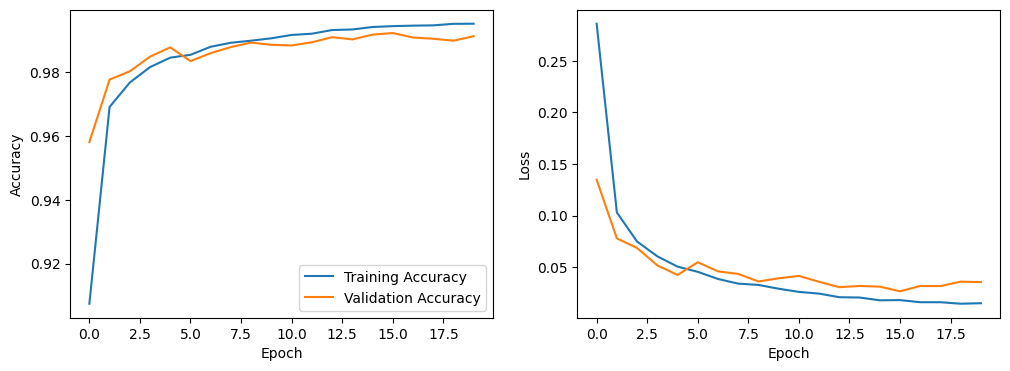

In [ ]:
# Plot the training and validation accuracy and loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

In [ ]:
y_pred=model.predict(x_test[0].reshape(1,28,28))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


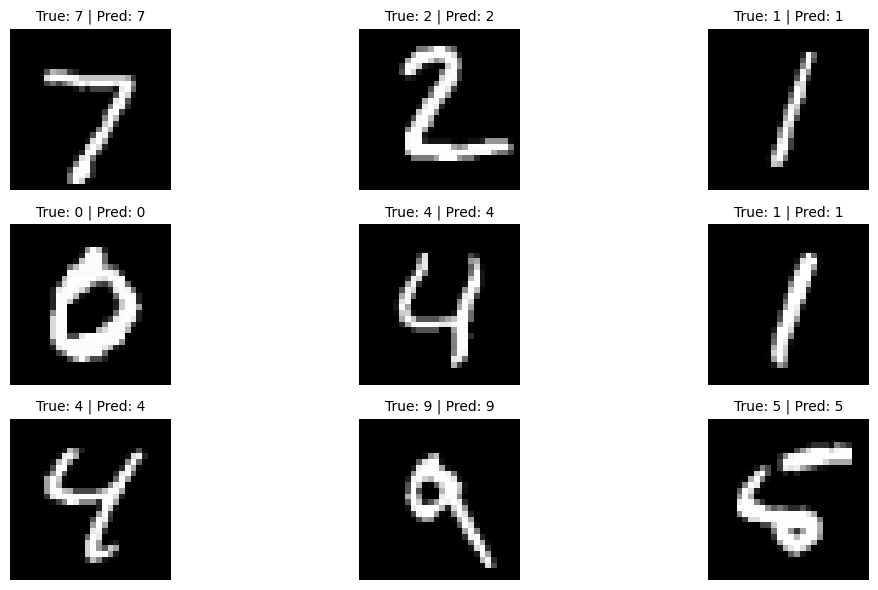

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
for j in range(9):
    plt.subplot(3, 3, j+1)
    plt.imshow(x_test[j], cmap='gray')
    y_pred = model.predict(x_test[j].reshape(1, 28, 28), verbose=0)
    predicted_label = y_pred.argmax()
    true_label = y_test[j]
    plt.title(f"True: {true_label} | Pred: {predicted_label}", fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()


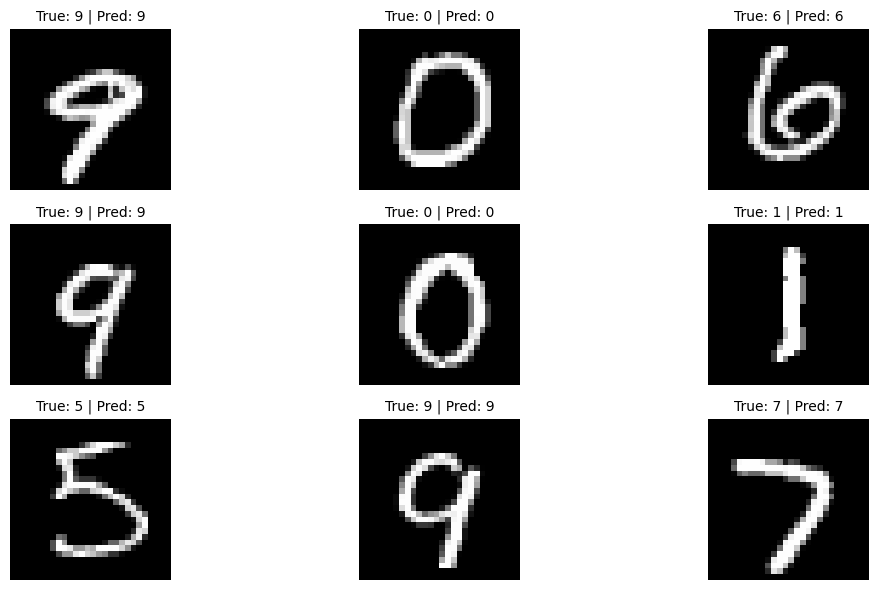

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
i=1
for j in range(9,18):
    plt.subplot(3, 3, i)
    plt.imshow(x_test[j], cmap='gray')
    y_pred = model.predict(x_test[j].reshape(1, 28, 28), verbose=0)
    predicted_label = y_pred.argmax()
    true_label = y_test[j]
    plt.title(f"True: {true_label} | Pred: {predicted_label}", fontsize=10)
    plt.axis('off')
    i+=1
plt.tight_layout()
plt.show()


In [ ]:
model=tf.keras.models.Sequential([
    tf.keras.layers.Reshape((28, 28, 1), input_shape=(28, 28)),
    tf.keras.layers.ConvLSTM1D(filters=40, kernel_size=(1),padding='valid'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(10,activation='relu'),
    tf.keras.layers.Dense(10,activation='softmax')
])

In [ ]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
history=model.fit(x_train,y_train,epochs=20,batch_size=BATCH_SIZE,validation_data=(x_test,y_test))

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 13ms/step - accuracy: 0.7030 - loss: 0.8846 - val_accuracy: 0.9358 - val_loss: 0.2197
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 12ms/step - accuracy: 0.9260 - loss: 0.2369 - val_accuracy: 0.9419 - val_loss: 0.1945
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.9455 - loss: 0.1772 - val_accuracy: 0.9534 - val_loss: 0.1498
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 12ms/step - accuracy: 0.9527 - loss: 0.1565 - val_accuracy: 0.9528 - val_loss: 0.1517
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9557 - loss: 0.1469 - val_accuracy: 0.9542 - val_loss: 0.1467
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 13ms/step - accuracy: 0.9601 - loss: 0.1261 - val_accuracy: 0.9658 - val_loss: 0.1110
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9615 - loss: 0.1236 - val_accuracy: 0.9689 - val_loss: 0.1031
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9653 -

Text(0, 0.5, 'Loss')

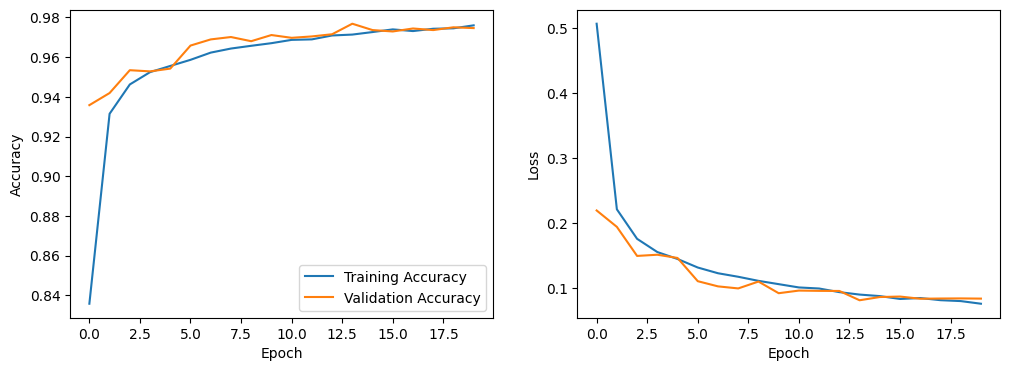

In [ ]:
# Plot the training and validation accuracy and loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

In [ ]:
y_pred=model.predict(x_test[0].reshape(1,28,28))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 646ms/step


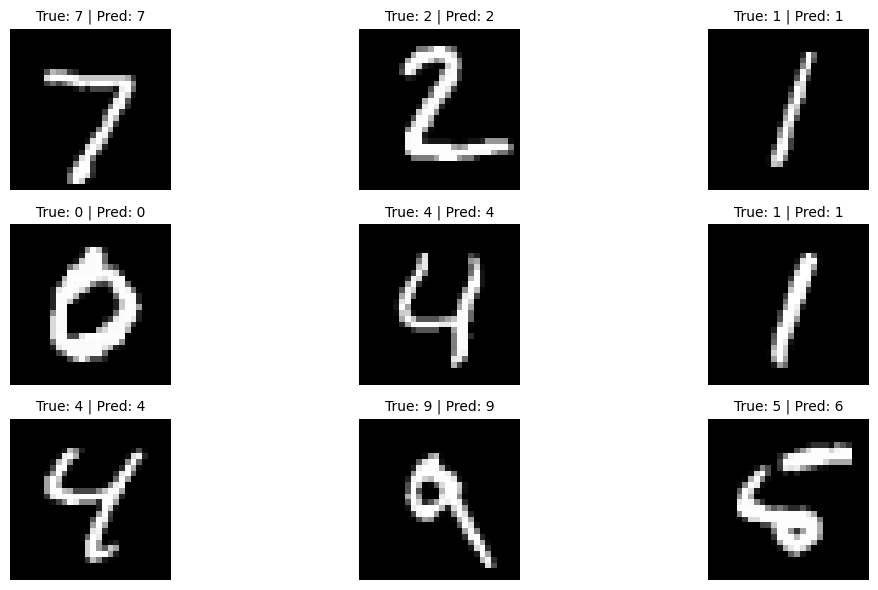

In [ ]:
plt.figure(figsize=(12, 6))
for j in range(9):
    plt.subplot(3, 3, j+1)
    plt.imshow(x_test[j], cmap='gray')
    y_pred = model.predict(x_test[j].reshape(1, 28, 28), verbose=0)
    predicted_label = y_pred.argmax()
    true_label = y_test[j]
    plt.title(f"True: {true_label} | Pred: {predicted_label}", fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()


----------------------------------------------

$$ Wish \space you \space all \space the \space best \space ♡ $$
$$ Abdelrahman \space Eid $$